# Phase 2: Exploratory Data Analysis (EDA)
Setting up the environment and importing the required libraries as per the CRISP-DM methodology.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
# Load the data
df = pd.read_csv('/Users/dovicohen/Library/CloudStorage/OneDrive-RMITUniversity/Commerce BP357/BCOM S1 2026/ISYS2047/A3/ISYS-A3/data/personal-loan.csv')

#Inspect structure and missing values
print("Data Information:")
df.info()

print("\nData Shape:")
print(df.shape)

Data Information:
<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         6000 non-null   int64  
 1   age                 5620 non-null   float64
 2   yrs_experience      5636 non-null   float64
 3   family_size         5615 non-null   float64
 4   education_level     6000 non-null   str    
 5   income              5623 non-null   float64
 6   mortgage_amt        6000 non-null   int64  
 7   credit_card_acct    6000 non-null   str    
 8   credit_card_spend   6000 non-null   float64
 9   share_trading_acct  6000 non-null   int64  
 10  fixed_deposit_acct  6000 non-null   int64  
 11  online_acct         6000 non-null   str    
 12  personal_loan       6000 non-null   str    
dtypes: float64(5), int64(4), str(4)
memory usage: 609.5 KB

Data Shape:
(6000, 13)


*Observation: The dataset contains 6000 rows and 13 columns. There are missing values identified in the age, yrs_experience, family_size, and income columns.*

In [6]:
# Summary statistics (transposed for readability)
print("\nSummary Statistics:")
display(df.describe().T)


Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
customer_id,6000.0,3027.886667,1723.488432,3.0,1553.75,3045.5,4511.0,6000.0
age,5620.0,45.556940,13.373778,23.0,34.00,45.0,56.0,92.0
yrs_experience,5636.0,21.182221,13.247945,0.0,10.00,21.0,32.0,65.0
family_size,5615.0,2.468566,1.215636,1.0,1.00,2.0,4.0,7.0
income,5623.0,88.143873,48.736053,8.0,52.00,82.0,118.0,300.0
mortgage_amt,6000.0,67.585667,88.155099,0.0,0.00,0.0,125.0,617.0
credit_card_spend,6000.0,0.627467,1.423450,0.0,0.00,0.0,0.4,9.5
share_trading_acct,6000.0,0.099167,0.298911,0.0,0.00,0.0,0.0,1.0
fixed_deposit_acct,6000.0,0.078167,0.268456,0.0,0.00,0.0,0.0,1.0


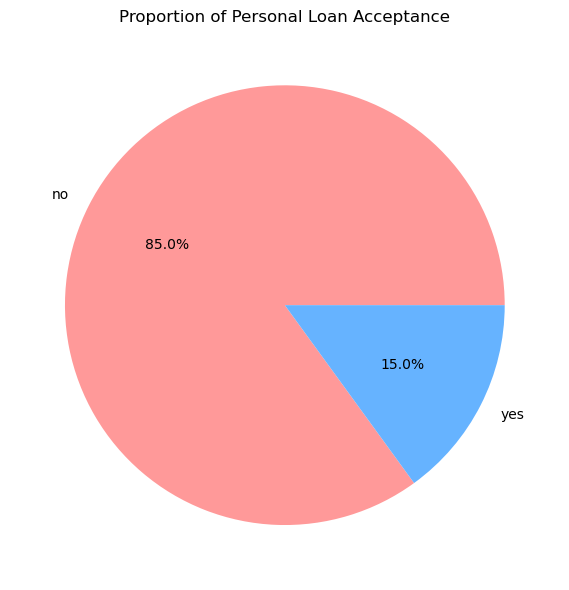

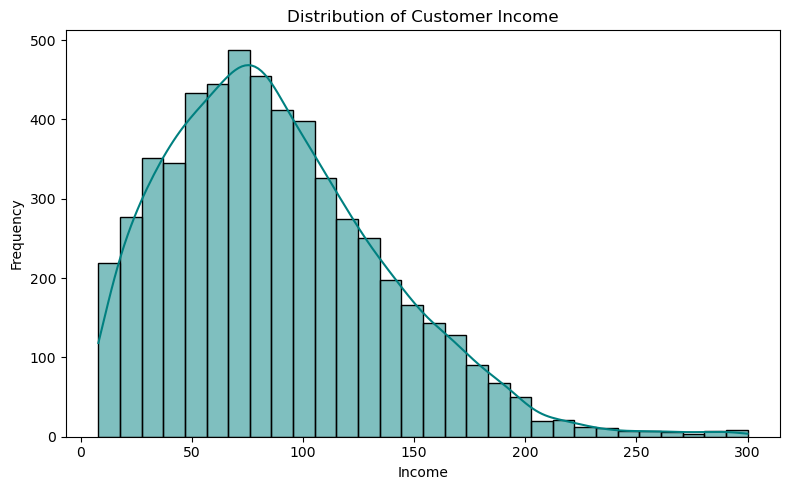

In [7]:
# Univariate: Pie chart for categorical proportions (Target Variable)
plt.figure(figsize=(6, 6))
outcome_counts = df['personal_loan'].value_counts()
plt.pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Proportion of Personal Loan Acceptance')
plt.tight_layout()
plt.savefig("target_proportion_pie.png", dpi=300)
plt.show()

# Univariate: Histogram for continuous variables
plt.figure(figsize=(8, 5))
sns.histplot(df['income'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribution of Customer Income')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("income_histogram.png", dpi=300)
plt.show()

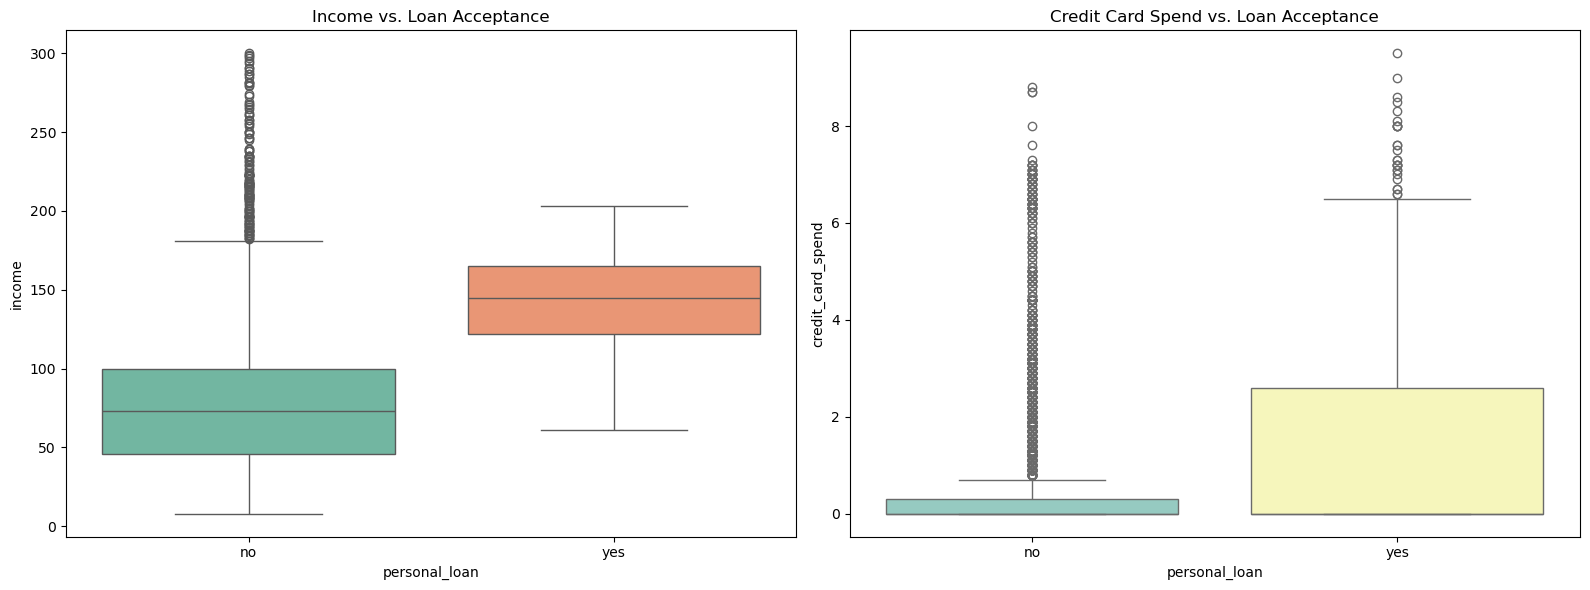

In [9]:
# Bivariate & Outlier Detection: Subplot Grids with Box Plots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='personal_loan', y='income', ax=ax[0], hue='personal_loan', palette='Set2', legend=False)
ax[0].set_title('Income vs. Loan Acceptance')

sns.boxplot(data=df, x='personal_loan', y='credit_card_spend', ax=ax[1], hue='personal_loan', palette='Set3', legend=False)
ax[1].set_title('Credit Card Spend vs. Loan Acceptance')

plt.tight_layout()
plt.savefig("financial_boxplots.png", dpi=300)
plt.show()